In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
import torch
from transformers import AutoTokenizer,AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import KFold
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
from tqdm import tqdm

torch.cuda.empty_cache()

/opt/modules/i12g/anaconda/envs/ptr-1-4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seqs = pd.read_csv('data/Table_EV4.tsv', sep='\t')
seqs = seqs[['EnsemblGeneID','ProteinSequence']]
seqs = seqs[:100]

tokenizer = AutoTokenizer.from_pretrained("../esm2_t15_6M_UR50D")
input = tokenizer(list(seqs['ProteinSequence']),return_tensors="pt",padding=True, truncation=True, max_length=5000)
ids = seqs[seqs['ProteinSequence'].str.len() < 5000].index

In [3]:
model = AutoModelForSequenceClassification.from_pretrained("../esm2_t33_650M_UR50D",num_labels=100)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval();

Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at ../esm2_t33_650M_UR50D and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
def run_esm2(input, batch_size):
    logits = []
    model.eval()
    
    with torch.no_grad():

        for i in tqdm(range(0, len(input["input_ids"]), batch_size)):
            batch_input = {k: v[i:i+batch_size].to(device) for k, v in input.items()}
            output = model(**batch_input)
            logits.append(output.logits.cpu())
            print("1")
    logits = torch.cat(logits, dim=0)
    logits_df = pd.DataFrame(logits)
    logits_df = logits_df.add_prefix("logit_")
    logits_df['EnsemblGeneID'] = seqs_subset['EnsemblGeneID']
    return logits_df
   
logits_df = run_esm2(input,2)

In [5]:
def data_prep_melt(ptr_path='data/Table_EV3.tsv'):

    ptr = pd.read_csv(ptr_path, sep='\t')
    ptr = ptr[[col for col in ptr.columns if "mRNA" not in col]]
    ptr = ptr[[col for col in ptr.columns if "protein" not in col]]
    id_vars = ptr.columns[:4]
    value_vars = ptr.columns[4:] 

    ptr_long = ptr.melt(id_vars=id_vars, value_vars=value_vars, 
                var_name='tissue', value_name='PTR')
    ptr_long['tissue'] = ptr_long['tissue'].str.replace('_PTR', '', regex=False)
    ptr_long['PTR'] = pd.to_numeric(ptr_long['PTR'], errors='coerce')
    ptr_long = ptr_long.dropna(subset=['PTR'])

    ptr_long = ptr_long[ptr_long.columns.drop(['GeneName', 'EnsemblTranscriptID', 'EnsemblProteinID'])]

    return ptr_long

ptr_long = data_prep_melt()


In [7]:
def mixed_model(features, ptr_long):

    merged = pd.merge(ptr_long, features, on='EnsemblGeneID', how='left')
    merged = merged.dropna()
    merged['tissue'] = merged['tissue'].astype('category')
    merged.columns = merged.columns.str.replace('.', '_', regex=False)
    

    features = features.columns.drop('EnsemblGeneID')
    features = features.str.replace('.', '_', regex=False)

        
    fixed_effects = 'C(tissue) + ' + ' + '.join(features) 
    #print(fixed_effects)
    formula = f'PTR ~ {fixed_effects}'

    predicted_ptr = np.zeros(len(merged))
    coefs_list = []
    intercepts_list = []
    
    kf = KFold(n_splits=10, shuffle=True)
    for train_idx, test_idx in kf.split(merged):
        
        merged_train = merged.iloc[train_idx]
        model = smf.mixedlm(formula, data=merged_train, groups=merged_train['EnsemblGeneID'])

        result = model.fit()

        predicted_ptr[test_idx] = result.predict(merged.iloc[test_idx])
        coefs_list.append(result.params)
        intercepts_list.append(result.params.get('Intercept', np.nan))

    pred_ptr_df = merged[['EnsemblGeneID','tissue','PTR']]
    pred_ptr_df['predicted_PTR'] = predicted_ptr

    return coefs_list, intercepts_list, pred_ptr_df

logits_df = pd.read_csv("data/esm2_t33_650M_UR50D_100_embed.csv")
coefs_list, intercepts_list, pred_ptr_df = mixed_model(logits_df, ptr_long)

/scratch/tmp/s_jgeis/ipykernel_280911/3644540149.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_ptr_df['predicted_PTR'] = predicted_ptr


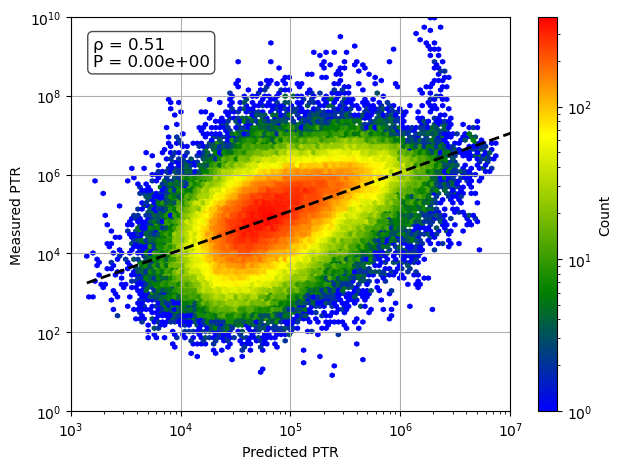

In [8]:
def hexbin(pred_ptr_df):

    ptr = pred_ptr_df['PTR']
    ptr_pred = pred_ptr_df['predicted_PTR']
    rho, pval = spearmanr(ptr_pred, ptr)

    pred_exp = 10**ptr_pred
    
    ptr_exp = 10**ptr

    colors = [
        (0.0, "blue"),
        (0.3, "green"),
        (0.7, "yellow"),
        (1  , "red"),
    ]

    custom_cmap = LinearSegmentedColormap.from_list("blue_yellow_red", colors)

    hb =plt.hexbin(pred_exp, ptr_exp,gridsize=100, 
            xscale = 'log',yscale = 'log',cmap=custom_cmap, bins = 'log' ,mincnt=1  )

    m, b = np.polyfit(ptr_pred, ptr, 1)
    x_fit = np.linspace(ptr_pred.min(), ptr.max(), 100)
    y_fit = m * x_fit + b
    
    cb = plt.colorbar(hb)
    cb.set_label('Count')
    plt.plot(10**x_fit, 10**y_fit, color='black', linestyle='--', linewidth=2, label='Fit line')
    plt.xlim(1e3, 1e7)
    plt.ylim(1, 1e10)
    plt.text(
        0.05, 0.95, f'ρ = {float(rho):.2f}\nP = {float(pval):.2e}',
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
    plt.xlabel('Predicted PTR')
    plt.ylabel('Measured PTR')
    plt.grid()
    plt.tight_layout()
    plt.show()

hexbin(pred_ptr_df)

EnsemblGeneID                                        ENSG00000155657
ProteinSequence    MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...
Name: 10714, dtype: object


(0.0, 100.0)

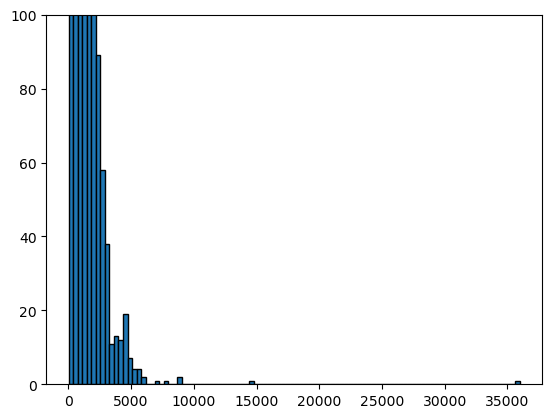

In [ ]:
genelengths = [len(seqs['ProteinSequence'][i]) for i in range(len(seqs['ProteinSequence']))]

plt.hist(genelengths, bins=100, edgecolor='black')
plt.ylim(0, 100)